# 05 — SHAP Explainability & Fairness Audit

**Goal:** Make every risk decision explainable and fair.

This notebook fulfils two regulatory requirements:
1. **Right to Explanation** (GDPR Article 22): Show the top factors that
   drove each individual decision using SHAP.
2. **Fair Lending**: Audit demographic parity across gender and age groups
   to detect and document disparate impact.

## Contents
1. Load model and test data
2. Global SHAP feature importance (bar + beeswarm)
3. Interaction SHAP: ext_source_product × credit_income_ratio  ← NEW
4. Individual explanations: One GREEN, YELLOW, RED applicant
5. Fairness audit: gender and age band parity + disparity bar chart  ← UPDATED
6. PSI drift monitoring on a synthetic reference set
7. Risk scorecard — score-to-points mapping  ← NEW

In [1]:
import sys, warnings, os
from pathlib import Path

_root = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path().resolve().parent
sys.path.insert(0, str(_root / 'src'))
warnings.filterwarnings('ignore')

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models import DefaultClassifier
from utils.config import load_config  # side-effect: os.chdir(project_root)
from utils.fairness_audit import run_fairness_audit, add_age_band
from training.evaluate import compute_psi

sns.set_theme(style='whitegrid')
cfg = load_config()

clf  = DefaultClassifier.load('outputs/models', cfg)
base_model = clf.model       # XGBClassifier — used for TreeExplainer
print('Model loaded. CWD:', os.getcwd())

2026-04-08 00:19:28 | INFO     | models.xgboost_classifier | Model loaded from outputs\models
Model loaded. CWD: C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\proactive-defaulter-flagging-system


## 1. Load Test Data

In [2]:
master = pd.read_csv('data/processed/feature_cache/master_features.csv')
sk_ids = master['SK_ID_CURR'].values          # keep for fairness join

obj_cols     = master.select_dtypes('object').columns.tolist()
high_missing = master.columns[master.isnull().mean() > 0.5].tolist()
X_raw = master.drop(columns=['TARGET', 'SK_ID_CURR'] + obj_cols + high_missing, errors='ignore')
X = X_raw.reindex(columns=clf.feature_columns, fill_value=0).fillna(X_raw.median(numeric_only=True))
y = master['TARGET']

# Sample for SHAP (TreeExplainer is fast but 50K still takes time)
sample_size = 3000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[sample_idx]

print(f'Features: {X.shape[1]}   |   SHAP sample: {len(X_sample)}')

Features: 141   |   SHAP sample: 3000


## 2. Global SHAP Feature Importance

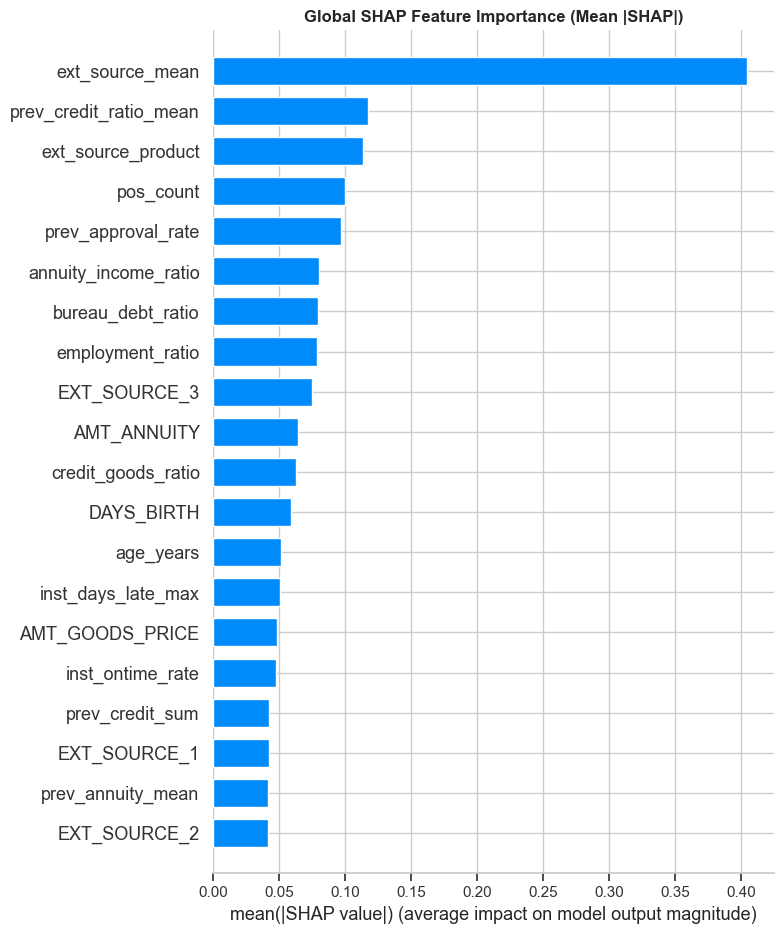

In [3]:
explainer   = shap.TreeExplainer(base_model)
shap_values = explainer.shap_values(X_sample)

os.makedirs('outputs/figures', exist_ok=True)

# --- Bar plot: mean |SHAP| ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=20, show=False)
plt.title('Global SHAP Feature Importance (Mean |SHAP|)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/05_shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

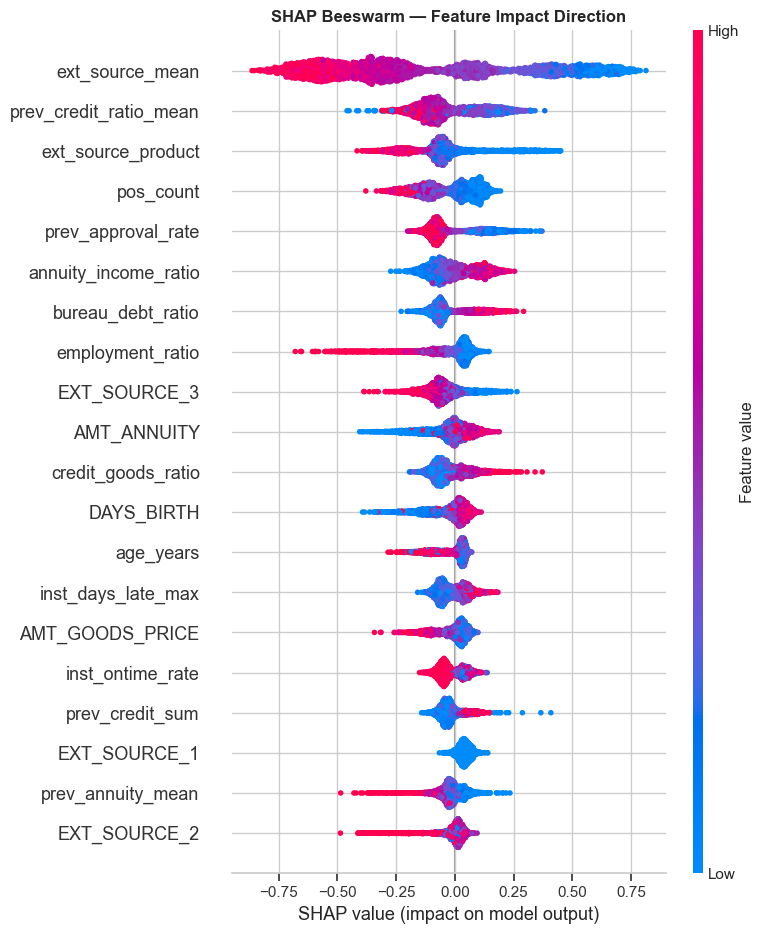

In [4]:
# Beeswarm: shows direction of each feature's impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/05_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Interaction SHAP — ext_source_product × credit_income_ratio

`ext_source_product` (EXT1 × EXT2 × EXT3) was the top Mutual Information feature in NB02.
The dependence plot below colours each point by `credit_income_ratio` to reveal
interactions: applicants with *low* external scores *and* high debt-burden are
the deepest in the RED band.

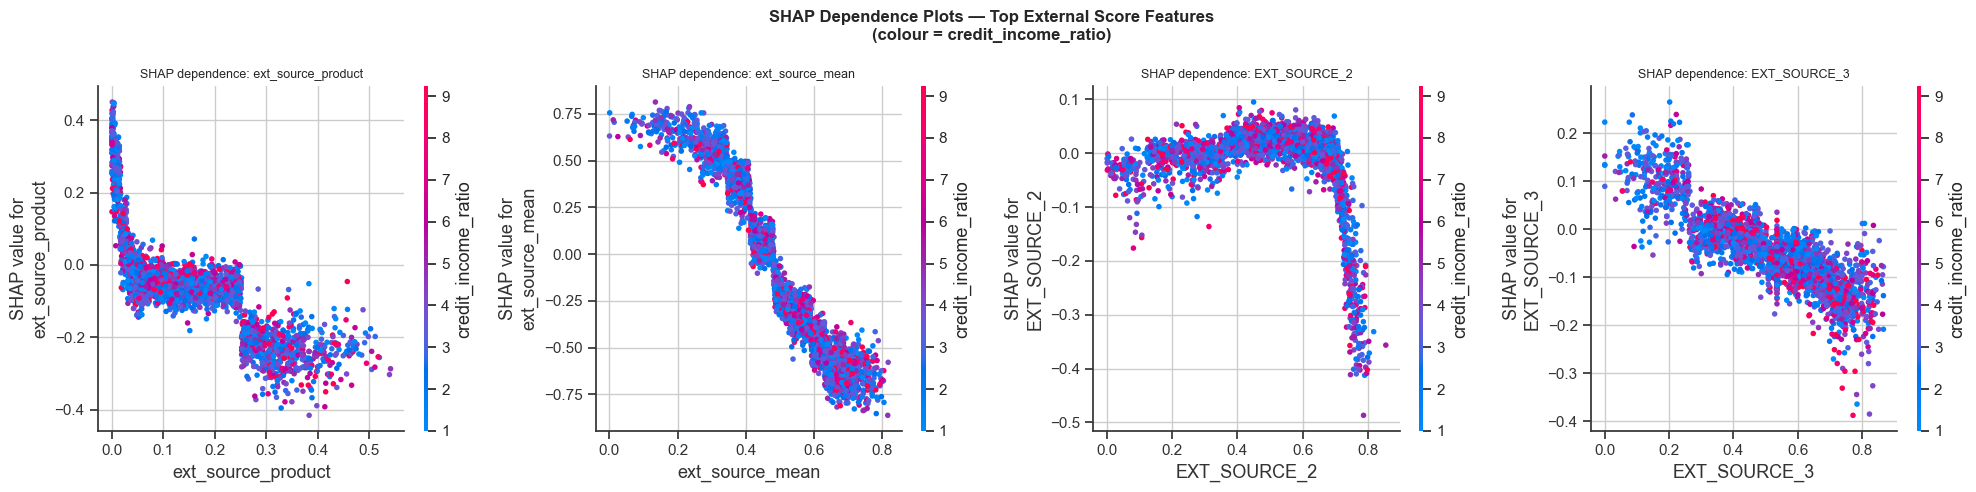

In [5]:
top_features = [
    'ext_source_product', 'ext_source_mean', 'EXT_SOURCE_2',
    'EXT_SOURCE_3', 'credit_income_ratio', 'annuity_income_ratio',
]

# Only plot features that are in X_sample
plot_feats = [f for f in top_features if f in X_sample.columns]

fig, axes = plt.subplots(1, len(plot_feats[:4]), figsize=(5 * len(plot_feats[:4]), 5))
if len(plot_feats[:4]) == 1:
    axes = [axes]

for ax, feat in zip(axes, plot_feats[:4]):
    feat_idx  = list(X_sample.columns).index(feat)
    # Interaction colouring: use credit_income_ratio if available, else auto
    int_feat = 'credit_income_ratio' if 'credit_income_ratio' in X_sample.columns else 'auto'
    shap.dependence_plot(
        feat_idx, shap_values, X_sample,
        interaction_index=int_feat,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP dependence: {feat}', fontsize=9)

plt.suptitle('SHAP Dependence Plots — Top External Score Features\n'
             '(colour = credit_income_ratio)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/05_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Individual Applicant Explanations

One RED, one YELLOW, and one GREEN applicant explained via SHAP waterfall.
The waterfall shows the additive contribution of each feature to the
departure from the model's base value (expected prediction).


--- RED applicant (index=0, risk_score=0.289) ---


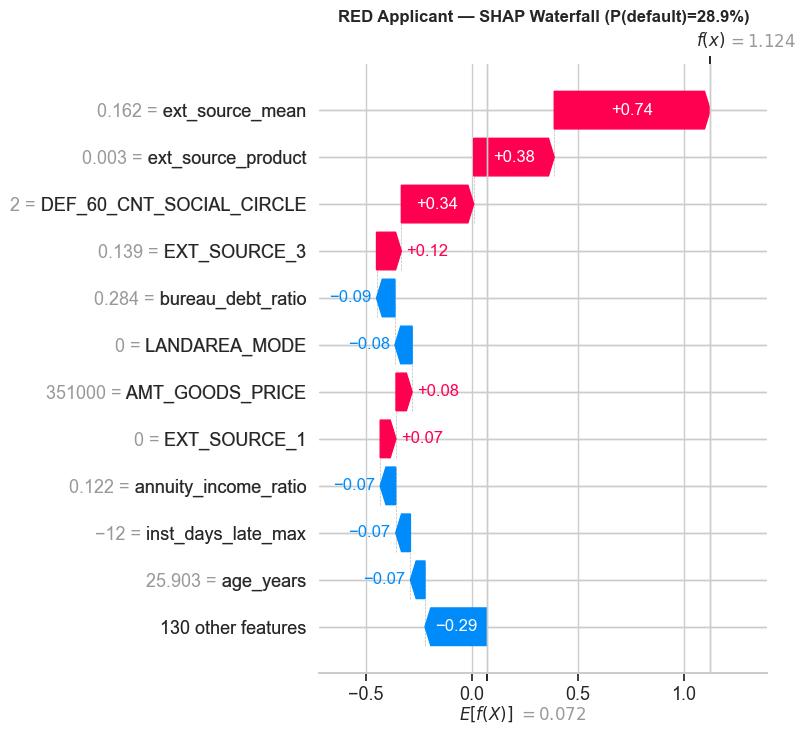


--- YELLOW applicant (index=4, risk_score=0.058) ---


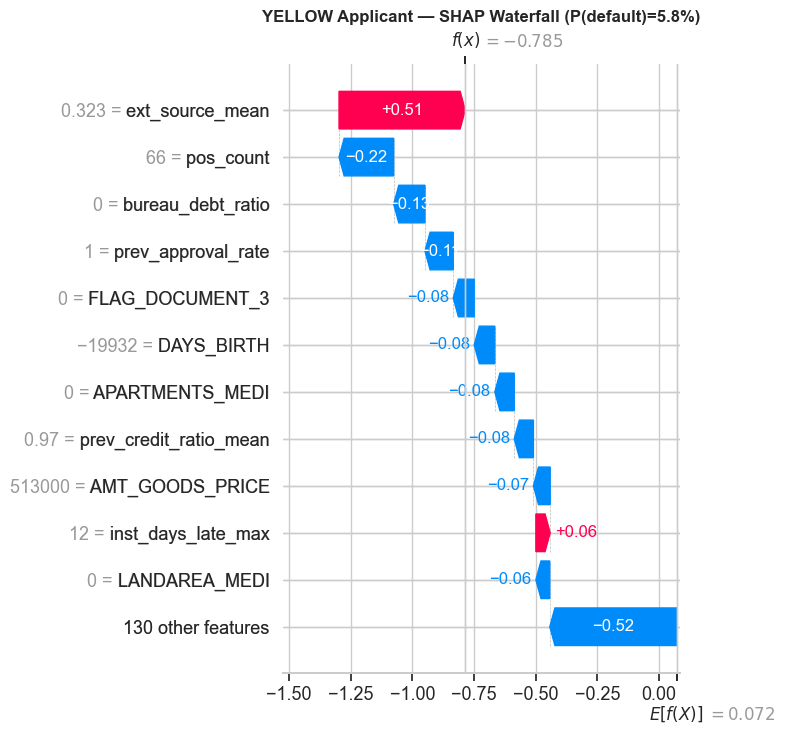


--- GREEN applicant (index=1, risk_score=0.032) ---


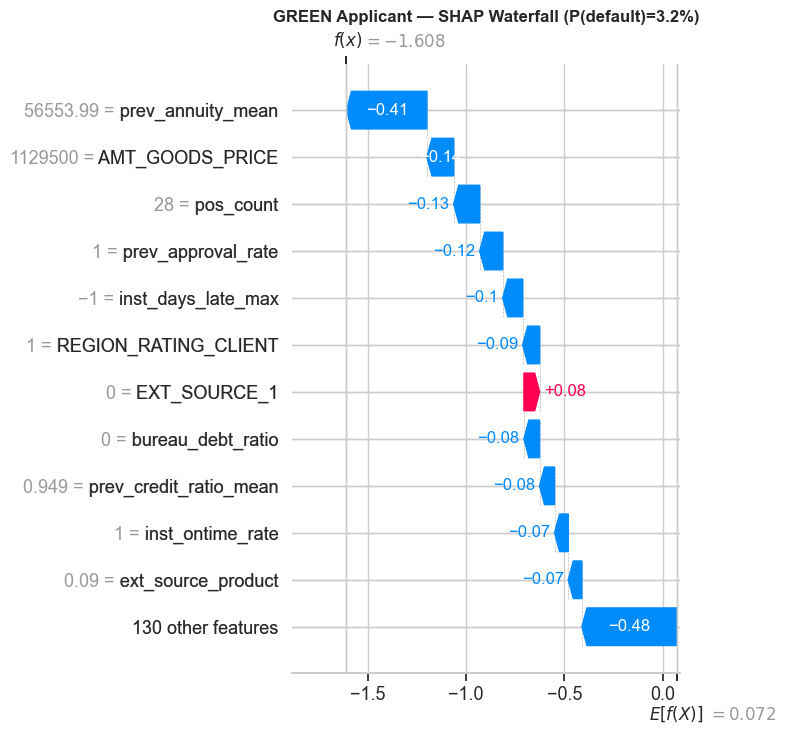

In [6]:
proba = clf.predict_proba(X)
tl    = clf.predict_traffic_light(X)

# Pick one representative applicant per band
explanations_cfg = [
    ('RED',    tl[tl['risk_band'] == 'RED'].index[0]),
    ('YELLOW', tl[tl['risk_band'] == 'YELLOW'].index[0]),
    ('GREEN',  tl[tl['risk_band'] == 'GREEN'].index[0]),
]

shap_expl = explainer(X_sample)   # Explanation object for sample rows

# Map band indices to sample positions (use sample if possible, else full X)
for band, idx in explanations_cfg:
    if idx in X_sample.index:
        row_pos_in_expl = list(X_sample.index).index(idx)
        sv = shap_expl[row_pos_in_expl]
    else:
        # Recompute for this specific row
        sv = explainer(X.loc[[idx]])[0]

    p = proba[X.index.get_loc(idx)]
    print(f'\n--- {band} applicant (index={idx}, risk_score={p:.3f}) ---')
    plt.figure(figsize=(10, 4))
    shap.plots.waterfall(sv, max_display=12, show=False)
    plt.title(f'{band} Applicant — SHAP Waterfall (P(default)={p:.1%})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'outputs/figures/05_shap_waterfall_{band.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 5. Fairness Audit — Gender & Age Band Parity

**Metrics:**
- **Parity difference** = max group default rate − min group default rate
  (< 5pp = PASS under our tolerance)
- **Disparate impact ratio** (4/5ths rule): min rate / max rate ≥ 0.80 = PASS

NB01 found: males 10.2 % vs females 7.0 % — a ~3.2 pp gap.
The audit below confirms these numbers and flags whether they breach thresholds.

In [7]:
# Build prediction table for master rows (50K) joined with app demographics
tl = clf.predict_traffic_light(X)
tl_df = pd.DataFrame({
    'SK_ID_CURR': sk_ids,
    'risk_band':  tl['risk_band'].values,
    'risk_score': tl['risk_score'].values,
})

app_raw = pd.read_csv(
    cfg.data.application_train,
    usecols=['SK_ID_CURR', 'TARGET', 'CODE_GENDER', 'DAYS_BIRTH']
)
app_raw = add_age_band(app_raw)

# Join: only master rows that exist in app_raw (inner join on SK_ID_CURR)
app_master = app_raw.merge(tl_df, on='SK_ID_CURR', how='inner')
print(f'Joined rows: {len(app_master)}  (master: {len(tl_df)}, train: {len(app_raw)})')

# ---------- Fairness audit on actual labels ----------
fairness_report = run_fairness_audit(
    app_master,
    label_col='TARGET',
    protected_cols=['CODE_GENDER', 'age_band'],
    parity_tolerance=cfg.fairness.parity_tolerance,
)
os.makedirs('outputs/reports', exist_ok=True)
fairness_report.to_csv('outputs/reports/fairness_report.csv', index=False)
print('\nFairness Report:')
print(fairness_report.to_string(index=False))
fairness_report

Joined rows: 50000  (master: 50000, train: 307511)
2026-04-08 00:20:16 | INFO     | utils.fairness_audit | Fairness [CODE_GENDER]: parity_diff=0.1026 | disparate_impact=0.0000 | FAIL
2026-04-08 00:20:16 | INFO     | utils.fairness_audit | Fairness [age_band]: parity_diff=0.0551 | disparate_impact=0.5084 | FAIL

Fairness Report:
  attribute group_value  n_applicants  default_rate  parity_diff  disparate_impact_ratio  passes_parity  passes_4_5ths_rule
CODE_GENDER           F         32824      0.068974     0.102597                0.000000          False               False
CODE_GENDER           M         17174      0.102597     0.102597                0.000000          False               False
CODE_GENDER         XNA             2      0.000000     0.102597                0.000000          False               False
   age_band         <30          7335      0.112065     0.055097                0.508353          False               False
   age_band       30-50         25919      0.08680

,attribute,group_value,n_applicants,default_rate,parity_diff,disparate_impact_ratio,passes_parity,passes_4_5ths_rule
0,CODE_GENDER,F,32824,0.068974,0.102597,0.000000,False,False
1,CODE_GENDER,M,17174,0.102597,0.102597,0.000000,False,False
2,CODE_GENDER,XNA,2,0.000000,0.102597,0.000000,False,False
3,age_band,<30,7335,0.112065,0.055097,0.508353,False,False
4,age_band,30-50,25919,0.086809,0.055097,0.508353,False,False
5,age_band,>50,16746,0.056969,0.055097,0.508353,False,False


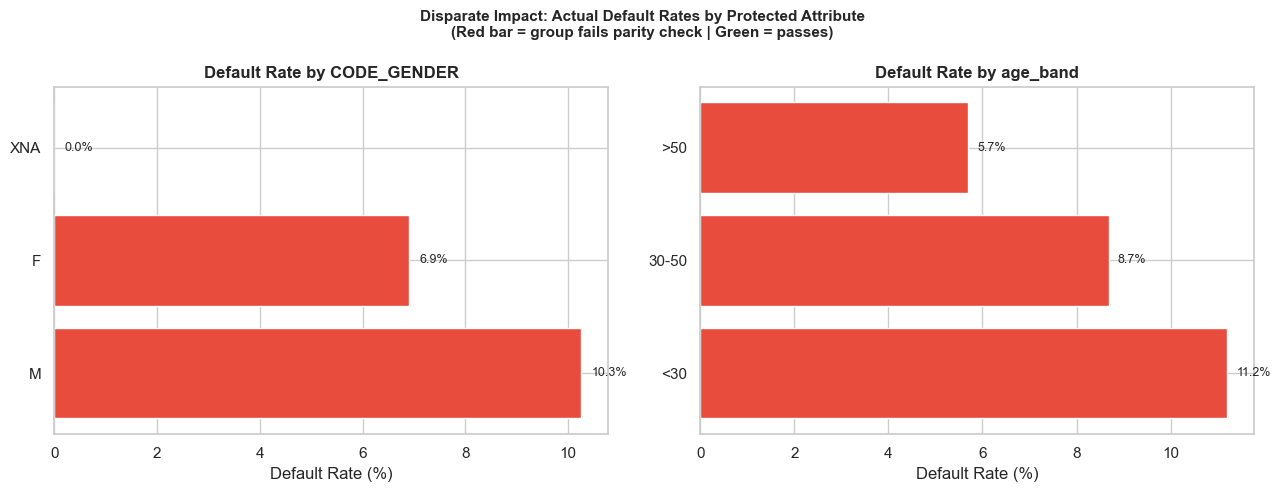

Gender parity gap:   10.26 pp
Age band parity gap: 5.51 pp


In [8]:
# ---------- Disparate impact bar chart ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for attr, ax in [('CODE_GENDER', axes[0]), ('age_band', axes[1])]:
    sub = fairness_report[fairness_report['attribute'] == attr].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    sub = sub.sort_values('default_rate', ascending=False)
    bar_colors = ['#e74c3c' if not p else '#2ecc71' for p in sub['passes_parity']]
    bars = ax.barh(sub['group_value'].astype(str), sub['default_rate'] * 100, color=bar_colors)
    ax.set_xlabel('Default Rate (%)')
    ax.set_title(f'Default Rate by {attr}', fontweight='bold')
    for bar, dr in zip(bars, sub['default_rate']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{dr*100:.1f}%', va='center', fontsize=9)

plt.suptitle('Disparate Impact: Actual Default Rates by Protected Attribute\n'
             '(Red bar = group fails parity check | Green = passes)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/05_fairness_disparate_impact.png', dpi=150, bbox_inches='tight')
plt.show()

parity_gender = fairness_report[fairness_report['attribute'] == 'CODE_GENDER']['parity_diff'].values
parity_age    = fairness_report[fairness_report['attribute'] == 'age_band']['parity_diff'].values
if len(parity_gender):
    print(f'Gender parity gap:   {parity_gender[0]*100:.2f} pp')
if len(parity_age):
    print(f'Age band parity gap: {parity_age[0]*100:.2f} pp')

## 5. PSI Drift Monitoring

PSI value: 0.0032
Status: ✅ STABLE — No significant score distribution shift


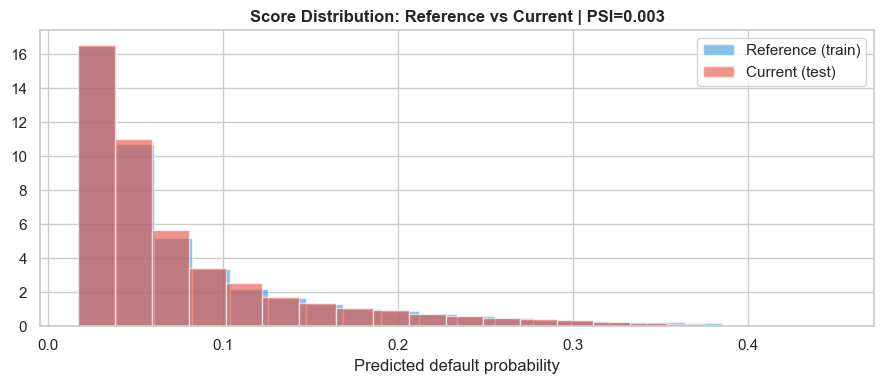

In [9]:
# Simulate a 'reference' distribution (first 60%) and 'current' (last 20%)
n = len(proba)
ref_scores = proba[:int(n * 0.6)]
cur_scores = proba[int(n * 0.8):]

psi_value = compute_psi(ref_scores, cur_scores, n_bins=10)
print(f'PSI value: {psi_value:.4f}')
if psi_value < 0.1:
    print('Status: ✅ STABLE — No significant score distribution shift')
elif psi_value < 0.25:
    print('Status: ⚠️  WARNING — Moderate shift detected, monitor closely')
else:
    print('Status: 🔴 CRITICAL — Significant shift, consider retraining')

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ref_scores, bins=20, alpha=0.6, color='#3498db', density=True, label='Reference (train)')
ax.hist(cur_scores, bins=20, alpha=0.6, color='#e74c3c', density=True, label='Current (test)')
ax.set_xlabel('Predicted default probability')
ax.set_title(f'Score Distribution: Reference vs Current | PSI={psi_value:.3f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/05_psi_drift.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Risk Scorecard — Score-to-Points Mapping

Credit professionals prefer a single integer score (e.g., 300-850 like FICO) over
raw probabilities.  The formula below converts the model's log-odds to a
**base 500 / PDO 20** scorecard (industry standard):

$$\text{Score} = 500 - 20 \times \log_2\!\left(\frac{p}{1-p}\right)$$

- **Higher score → lower risk** (inverse of probability)
- PDO = 20 means 20 points separates a doubling/halving of odds
- RED band typically < 450 | YELLOW 450-530 | GREEN > 530

Score distribution by risk band:
            mean  median  min  max  count
risk_band                                
GREEN      598.0   598.0  584  617  25701
RED        540.0   542.0  506  557   8970
YELLOW     572.0   573.0  557  584  15329


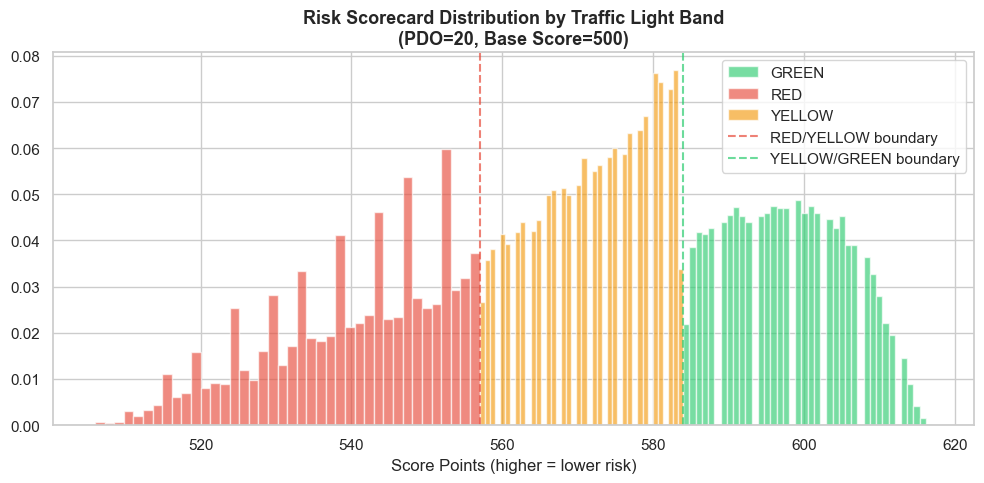


Scorecard saved → outputs/reports/risk_scores.csv  (50,000 rows)


In [10]:
pdo  = 20          # points to double the odds
base = 500         # score at odds = 1 (50% default prob)

# Convert calibrated probability to score
# Clip proba away from 0/1 to avoid -inf/+inf
p_clipped = np.clip(proba, 1e-6, 1 - 1e-6)
log_odds   = np.log2(p_clipped / (1 - p_clipped))
scores     = (base - pdo * log_odds).round().astype(int)

score_df = pd.DataFrame({
    'SK_ID_CURR': sk_ids,
    'risk_score_prob': proba,
    'score_points': scores,
    'risk_band': tl['risk_band'].values,
})

print('Score distribution by risk band:')
print(
    score_df.groupby('risk_band')['score_points']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .round(0)
    .to_string()
)

# Score distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
color_map = {'GREEN': '#2ecc71', 'YELLOW': '#f39c12', 'RED': '#e74c3c'}
for band, grp in score_df.groupby('risk_band'):
    ax.hist(grp['score_points'], bins=40, alpha=0.65,
            color=color_map.get(band, 'grey'), label=band, density=True)

ax.axvline(scores[tl['risk_band'].values == 'RED'].max()   if (tl['risk_band'].values == 'RED').any() else 0,
           color='#e74c3c', linestyle='--', alpha=0.7, label='RED/YELLOW boundary')
ax.axvline(scores[tl['risk_band'].values == 'GREEN'].min() if (tl['risk_band'].values == 'GREEN').any() else 0,
           color='#2ecc71', linestyle='--', alpha=0.7, label='YELLOW/GREEN boundary')

ax.set_xlabel('Score Points (higher = lower risk)', fontsize=12)
ax.set_title('Risk Scorecard Distribution by Traffic Light Band\n'
             f'(PDO={pdo}, Base Score={base})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/05_risk_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

# Save scorecard to CSV
score_df.to_csv('outputs/reports/risk_scores.csv', index=False)
print(f'\nScorecard saved → outputs/reports/risk_scores.csv  ({len(score_df):,} rows)')